# Preparation: import libraries and load data

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import pickle
import os
import joblib
import shap

from sklearn.base import BaseEstimator, TransformerMixin
from mrmr import mrmr_classif

In [2]:
# Models have been trained without feature names.
# This suppresses warnings about feature names.
import warnings
warnings.filterwarnings('ignore', message='X has feature names')

In [3]:
seed = 71

In [4]:
# SELECTION OF NEEDED PARAMETERS
# THE ONLY OTHER BOX TO BE MODIFIED IS THE LIST OF FEATURES TO BE USED IN THE MODEL

outcome = 'DCR'

# Indicate the model to be used ['CPH', 'ST', 'GBS', 'RSF', 'EST', 'SSVM']
file = "ET_bfs.joblib"

# Set this to True if you want to save figures/data, and False otherwise
save_output = True

In [5]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
# Ensure that the order of features in the test set matches that of the training set
X_test = X_test[X_train.columns]

y_train = pd.read_excel("Data/y_train.xlsx").iloc[:, 1].values
y_test  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1].values

y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [6]:
class MRMRSelector(BaseEstimator, TransformerMixin):
    def __init__(self, K=10):
        self.K = K
        self.selected_features_ = None

    def fit(self, X, y):
        # Convert through numpy first to guarantee a clean 0-based RangeIndex on
        # both X_df and y_s. Without this, CV-sliced DataFrames keep their original
        # non-contiguous index while pd.Series(y) gets 0..n, causing mrmr's internal
        # boolean indexer to raise IndexingError on index misalignment.
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        y_s  = pd.Series(np.array(y).ravel())
        self.selected_features_ = mrmr_classif(X_df, y_s, K=self.K)
        return self

    def transform(self, X):
        Xarr = np.array(X)
        cols = getattr(X, "columns", range(Xarr.shape[1]))
        X_df = pd.DataFrame(Xarr, columns=cols)
        return X_df[self.selected_features_].values

In [7]:
base = file.replace(".joblib", "")
name, fs = base.rsplit("_", 1)

if save_output:
    os.makedirs("Explainability", exist_ok=True)

pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
if fs != "none":
    # Get selected features - try multiple methods for compatibility
    if hasattr(fs_step, 'get_support'):
        mask = fs_step.get_support()
        feature_names = fs_step.feature_names_in_
        features_model = feature_names[mask]
    elif hasattr(fs_step, 'selected_features_'):
        # Direct access to selected features (e.g., MRMRSelector)
        features_model = np.array(fs_step.selected_features_)
    elif hasattr(fs_step, 'get_feature_names_out'):
        # For sklearn selectors that support get_feature_names_out
        features_model = fs_step.get_feature_names_out()
    else:
        raise AttributeError(f"Cannot extract selected features from {type(fs_step).__name__}")
    
    X_tr = X_train[features_model].reset_index(drop=True)
    X_t  = X_test[features_model].reset_index(drop=True)
    print(f"Feature selection applied — {len(features_model)} features: {features_model}")
else:
    features_model = list(X_train.columns)
    X_tr = X_train.reset_index(drop=True)
    X_t  = X_test.reset_index(drop=True)
    print(f"No feature selection — using all {len(features_model)} features.")

m = pipeline.named_steps.get("model", None)

Feature selection applied — 22 features: ['Sex' 'Age' 'Nefrectomy' 'M+ at diagnosis' 'IMDC Score at diagnosis'
 'TKI' 'Hb at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Lymph nodes metastases' 'Visceral metastases' 'Bone metastases'
 'Platelets at baseline' 'PLR at baseline' 'SII at baseline'
 'Histology_clearcell' 'Nivolumab_2ndline' 'log_Neutrophils at baseline'
 'log_Lymphocytes at baseline' 'log_Monocytes at baseline'
 'log_Eosinophils at baseline' 'log_NLR at baseline']


In [8]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_t)

In [9]:
# Expected values of the risk scores (= mean of the predicted values)

exp_value_tr = np.mean(y_pred_train)
print(f"Expected value TRAIN: {exp_value_tr.round(3)}")

exp_value_te = np.mean(y_pred_test)
print(f"Expected value TEST: {exp_value_te.round(3)}")

Expected value TRAIN: 0.608
Expected value TEST: 0.628


# Explainability analysis: building the explainer

In [10]:
# Train the explainer and generate explanations for the TEST set

explainer = shap.Explainer(m.predict, X_tr, seed=seed)
shap_values = explainer(X_t)

PermutationExplainer explainer: 114it [00:36,  3.11it/s]                         


Link the SHAP values to the corresponding original data (non-logarithmic and non-normalized), so that Explainability graphs refer to the original data

In [11]:
# Print the list of features selected by the feature selector
print(f'Features for training the model: \n{features_model} \n')

# Array with the original names of the selected features
features_original = np.array([n.removeprefix('log_') for n in features_model])
# Print the list of original selected features
print(f'Original features: \n{features_original}')

Features for training the model: 
['Sex' 'Age' 'Nefrectomy' 'M+ at diagnosis' 'IMDC Score at diagnosis'
 'TKI' 'Hb at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Lymph nodes metastases' 'Visceral metastases' 'Bone metastases'
 'Platelets at baseline' 'PLR at baseline' 'SII at baseline'
 'Histology_clearcell' 'Nivolumab_2ndline' 'log_Neutrophils at baseline'
 'log_Lymphocytes at baseline' 'log_Monocytes at baseline'
 'log_Eosinophils at baseline' 'log_NLR at baseline'] 

Original features: 
['Sex' 'Age' 'Nefrectomy' 'M+ at diagnosis' 'IMDC Score at diagnosis'
 'TKI' 'Hb at baseline' 'IMDC Score at baseline IO' 'KPS'
 'Lymph nodes metastases' 'Visceral metastases' 'Bone metastases'
 'Platelets at baseline' 'PLR at baseline' 'SII at baseline'
 'Histology_clearcell' 'Nivolumab_2ndline' 'Neutrophils at baseline'
 'Lymphocytes at baseline' 'Monocytes at baseline'
 'Eosinophils at baseline' 'NLR at baseline']


In [12]:
# Load the corresponding non-logarithmised and non-normalised data
X_test_explainability = pd.read_excel('Data/X_test_expl.xlsx')

# Keep only the original features corresponding to those selected by the feature selector
X_test_explainability = X_test_explainability.loc[:,features_original]
X_test_explainability.columns

Index(['Sex', 'Age', 'Nefrectomy', 'M+ at diagnosis',
       'IMDC Score at diagnosis', 'TKI', 'Hb at baseline',
       'IMDC Score at baseline IO', 'KPS', 'Lymph nodes metastases',
       'Visceral metastases', 'Bone metastases', 'Platelets at baseline',
       'PLR at baseline', 'SII at baseline', 'Histology_clearcell',
       'Nivolumab_2ndline', 'Neutrophils at baseline',
       'Lymphocytes at baseline', 'Monocytes at baseline',
       'Eosinophils at baseline', 'NLR at baseline'],
      dtype='str')

In [13]:
# Set the feature names in the SHAP values
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c

# Link the SHAP values to the corresponding original data
shap_values.data = X_test_explainability.values

In [14]:
# Save the explainer and the SHAP values

if save_output:
    with open(f'Explainability/explainer.pkl', 'wb') as f:
        pickle.dump(explainer, f)
    with open(f'Explainability/shap_values.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

# Explainability plots - test set

## Beeswarm plots

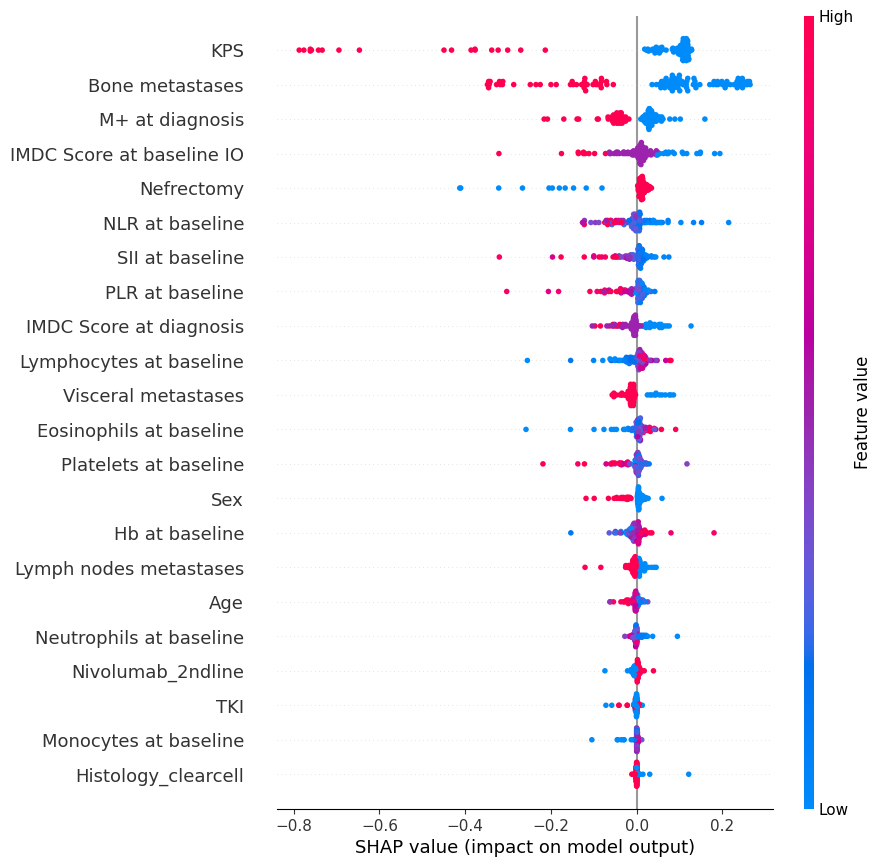

In [15]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_tr.shape[1], show=False)
if save_output:
    plt.savefig(f'Explainability/Beeswarm_complete.png', format='png', dpi=300, bbox_inches='tight')

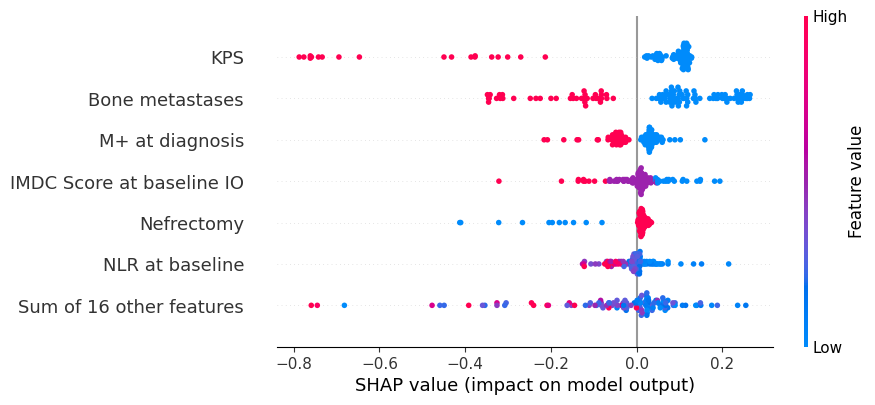

In [16]:
# Plot the SHAP values for the first 6 most important features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)
if save_output:
    plt.savefig(f'Explainability/Beeswarm_reduced.png', format='png', dpi=300, bbox_inches='tight')